# EEG_08b — GNN Subject-Specific Classification + Subject Ranking

Trains a GCN per subject (leave-one-session-out split) and ranks subjects
by test balanced accuracy.

| Section | Description |
|---------|-------------|
| §1 | Imports & Config |
| §2 | Dataset + session split |
| §3 | GCN model |
| §4 | Train / eval functions |
| §5 | Per-subject loop |
| §6 | Ranking + plot |

## 1 — Imports & Config

In [10]:
import json
import logging
import random
import re
import time
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s  %(levelname)-8s  %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('eeg08b')

project_root = next(
    (p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / '.git').exists()),
    Path.cwd(),
)
(project_root / 'checkpoints').mkdir(exist_ok=True)
(project_root / 'figures').mkdir(exist_ok=True)
log.info(f'project_root: {project_root}')

CONFIG = {
    'data_root':      str(project_root / 'data' / 'graphs_pruned_abs_pcc'),
    'n_classes':      4,
    'batch_size':     32,
    'epochs':         80,
    'lr':             1e-3,
    'early_stopping': 15,
    'seed':           42,
    'device':         'cuda' if torch.cuda.is_available() else 'cpu',
    'hidden_dim':     64,
    'dropout':        0.3,
    'wandb_project':  'miralis-imagined-speech',
    'wandb_entity':   'uras-daniele22-politecnico-di-milano',
    'wandb_group':    'eeg08b_subject_specific',
}

# Normalizzazione per-trial (Bomatter 2024)
# True  = z-score per-canale per trial (rimuove variabilita inter-sessione)
# False = segnale grezzo dal .pt
USE_INSTANCE_NORM = True
log.info(f'USE_INSTANCE_NORM={USE_INSTANCE_NORM}')

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
n_params = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
log.info(f"device={CONFIG['device']}  seed={CONFIG['seed']}")


17:43:48  INFO      project_root: /home/daniele_u/miralis-hypergraph-imagined-speech
17:43:48  INFO      USE_INSTANCE_NORM=True
17:43:48  INFO      device=cuda  seed=42


## 2 — Dataset & Session Split

**Split strategy**: leave-one-session-out.
- Test  → ultima sessione (S005)
- Val   → penultima (S004)
- Train → tutte le altre (S001-S003)

Fallback a random 70/15/15 se soggetto ha < 3 sessioni.

In [11]:
_PAT       = re.compile(r'^P(\d+)_S(\d+)$')
_data_root = Path(CONFIG['data_root'])
assert _data_root.exists(), f'data_root not found: {_data_root}'

# label mapping
_raw_map = json.loads(
    (project_root / 'configs' / 'label_schemes' / 'labelid2cluster_concr4.json').read_text()
)
LABEL2CLUSTER = torch.zeros(110, dtype=torch.long)
for ws, cid in _raw_map.items():
    LABEL2CLUSTER[int(ws)] = int(cid)

# raccolta path per soggetto -> sessione
subj_sess_paths = defaultdict(lambda: defaultdict(list))
for p in sorted(_data_root.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess_paths[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ_IDS = sorted(subj_sess_paths.keys())
log.info(f'Soggetti: {len(ALL_SUBJ_IDS)}')

def session_split(subj_id):
    sess = subj_sess_paths[subj_id]
    sids = sorted(sess.keys())
    if len(sids) >= 3:
        train_paths = [p for s in sids[:-2] for p in sess[s]]
        val_paths   = list(sess[sids[-2]])
        test_paths  = list(sess[sids[-1]])
    else:
        all_p = [p for s in sids for p in sess[s]]
        rng   = random.Random(CONFIG['seed'])
        rng.shuffle(all_p)
        n = len(all_p)
        n_tr = int(n * 0.70); n_va = int(n * 0.15)
        train_paths = all_p[:n_tr]
        val_paths   = all_p[n_tr:n_tr+n_va]
        test_paths  = all_p[n_tr+n_va:]
    return train_paths, val_paths, test_paths


class EEGGraphDataset(TorchDataset):
    def __init__(self, pt_paths):
        self.paths = list(pt_paths)
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        d  = torch.load(self.paths[idx], weights_only=False)
        ea = d['edge_attr']
        if not isinstance(ea, torch.Tensor):
            ea = torch.tensor(np.asarray(ea), dtype=torch.float32)
        ea = ea.float()
        ew = ea if ea.dim() == 1 else ea[:, 0]
        y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
        x = d['x'].float()
        if USE_INSTANCE_NORM:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        return Data(x=x, edge_index=d['edge_index'].long(),
                    edge_weight=ew, y=LABEL2CLUSTER[y_word])


def build_loaders(tr, va, te):
    bs = CONFIG['batch_size']
    return (
        PyGDataLoader(EEGGraphDataset(tr), batch_size=bs, shuffle=True),
        PyGDataLoader(EEGGraphDataset(va), batch_size=bs, shuffle=False),
        PyGDataLoader(EEGGraphDataset(te), batch_size=bs, shuffle=False),
    )


def compute_class_weights(paths):
    labels = []
    for p in paths:
        d = torch.load(p, weights_only=False)
        y = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
        labels.append(int(LABEL2CLUSTER[y]))
    counts = np.bincount(labels, minlength=CONFIG['n_classes']).astype(float)
    counts = np.where(counts == 0, 1, counts)
    return torch.tensor(len(labels) / (CONFIG['n_classes'] * counts), dtype=torch.float32)


_s = torch.load(next(_data_root.rglob('trial_*.pt')), weights_only=False)
IN_CHANNELS = int(_s['x'].shape[1])
log.info(f'IN_CHANNELS={IN_CHANNELS}')


17:43:49  INFO      Soggetti: 74
17:43:49  INFO      IN_CHANNELS=384


## 3 — GCN Model

In [12]:
def _mlp_head(in_dim, out_dim, dropout):
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2), nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, out_dim),
    )


class GCNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, n_classes, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim,  hidden_dim)
        self.conv3 = GCNConv(hidden_dim,  hidden_dim)
        self.drop  = nn.Dropout(dropout)
        self.head  = _mlp_head(hidden_dim, n_classes, dropout)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        ew = getattr(data, 'edge_weight', None)
        x = F.relu(self.conv1(x, ei, ew)); x = self.drop(x)
        x = F.relu(self.conv2(x, ei, ew)); x = self.drop(x)
        x = F.relu(self.conv3(x, ei, ew))
        return self.head(global_mean_pool(x, data.batch))


log.info('GCN OK')


17:43:49  INFO      GCN OK


## 4 — Train & Evaluate

In [13]:
def train_one_subject(subj_id, train_loader, val_loader, class_weights):
    device = torch.device(CONFIG['device'])
    model  = GCNModel(IN_CHANNELS, CONFIG['hidden_dim'],
                      CONFIG['n_classes'], CONFIG['dropout']).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
    crit   = nn.CrossEntropyLoss(weight=class_weights.to(device))
    ckpt   = project_root / 'checkpoints' / f'eeg08b_P{subj_id:03d}.pt'

    run = wandb.init(
        project=CONFIG['wandb_project'], entity=CONFIG['wandb_entity'],
        group=CONFIG['wandb_group'],
        name=f"P{subj_id:03d}_GCN{'_norm' if USE_INSTANCE_NORM else ''}",
        config={**CONFIG, 'subject_id': subj_id,
                'use_instance_norm': USE_INSTANCE_NORM},
        reinit='finish_previous',
    )

    best_val_bacc, patience = -1.0, 0
    for epoch in range(CONFIG['epochs']):
        model.train()
        tr_preds, tr_labels = [], []
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            loss = nn.CrossEntropyLoss(weight=class_weights.to(device))(
                model(batch), batch.y)
            loss.backward(); opt.step()
            tr_preds.extend(model(batch).detach().argmax(1).cpu().numpy())
            tr_labels.extend(batch.y.cpu().numpy())

        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                val_preds.extend(model(batch).argmax(1).cpu().numpy())
                val_labels.extend(batch.y.cpu().numpy())

        vba = balanced_accuracy_score(val_labels, val_preds)
        wandb.log({'train/bacc': balanced_accuracy_score(tr_labels, tr_preds),
                   'val/bacc': vba, 'epoch': epoch})

        if vba > best_val_bacc:
            best_val_bacc = vba; patience = 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience += 1
        if patience >= CONFIG['early_stopping']:
            break

    model.load_state_dict(torch.load(ckpt, weights_only=True))
    run.summary['best_val_bacc'] = best_val_bacc
    run.finish()
    return model


def evaluate(model, loader):
    device = torch.device(CONFIG['device'])
    model.to(device).eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            preds.extend(model(batch).argmax(1).cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    preds, labels = np.array(preds), np.array(labels)
    return {
        'test_bacc': balanced_accuracy_score(labels, preds),
        'macro_f1':  f1_score(labels, preds, average='macro', zero_division=0),
        'cm':        confusion_matrix(labels, preds, labels=list(range(CONFIG['n_classes']))),
        'labels':    labels,
        'preds':     preds,
    }


## 5 — Per-Subject Training Loop

In [14]:
wandb.login()

SUBJECT_RESULTS = {}  # subj_id -> metrics dict

for subj_id in tqdm(ALL_SUBJ_IDS, desc='Subjects'):
    tr_paths, va_paths, te_paths = session_split(subj_id)
    if not te_paths:
        log.warning(f'P{subj_id:03d}: nessun trial di test, skip')
        continue

    tr_loader, va_loader, te_loader = build_loaders(tr_paths, va_paths, te_paths)
    cw = compute_class_weights(tr_paths)

    t0    = time.time()
    model = train_one_subject(subj_id, tr_loader, va_loader, cw)
    res   = evaluate(model, te_loader)
    res['train_time_s'] = round(time.time() - t0, 1)
    res['n_train'] = len(tr_paths)
    res['n_val']   = len(va_paths)
    res['n_test']  = len(te_paths)

    SUBJECT_RESULTS[subj_id] = res
    log.info(f"P{subj_id:03d}  test_bacc={res['test_bacc']:.4f}  "
             f"f1={res['macro_f1']:.4f}  t={res['train_time_s']}s")

log.info(f'Completati {len(SUBJECT_RESULTS)}/{len(ALL_SUBJ_IDS)} soggetti')


Subjects:   0%|          | 0/74 [00:00<?, ?it/s]

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/bacc,▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▅▆▇▆▇▇▇█▇▇█▇█████████
val/bacc,▂▂▂▂▂▃▅▂▄▄▃▄▅▃▁▃▄▆▄▆▅▃█▅▇█▇▅▄▃▆▄▇▄▃▃▆▅▄▆
best_val_bacc,0.33487
epoch,40
train/bacc,0.92015
val/bacc,0.31067


17:44:07  INFO      P000  test_bacc=0.2389  f1=0.2407  t=17.3s


epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
train/bacc,▁▁▁▁▁▂▂▂▂▄▃▄▄▄▅▅▆▆▇▇████
val/bacc,▃▄▃▄▁▂▃▂█▂▇▅▄▅▃▄▃▆▅▅▂▁▁▃
best_val_bacc,0.29807
epoch,23
train/bacc,0.85224
val/bacc,0.23232


17:44:18  INFO      P001  test_bacc=0.2217  f1=0.2152  t=9.9s


...

epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
train/bacc,▁▁▂▂▃▃▄▄▄▆▆▆▇▇▇▇████████
val/bacc,▆▆▆▅▄▃▅▄█▅▂▃▂▄▂▄▂▄▃▄▂▄▂▁
best_val_bacc,0.29191
epoch,23
train/bacc,0.9795
val/bacc,0.16324


18:01:38  INFO      P072  test_bacc=0.2946  f1=0.2892  t=9.2s


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924

epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
train/bacc,▁▁▁▁▂▂▂▂▂▂▁▃▃▂▃▂▄▄▄▃▃▅▅▅▇▇█▇█
val/bacc,▆▆▆▆▆▆▆▆▆▆▆▅▆█▆▆▆▆▆▇▆▃▂▁▁▂▃▄▄
best_val_bacc,0.46032
epoch,28
train/bacc,0.69073
val/bacc,0.22222


18:01:42  INFO      P073  test_bacc=0.4286  f1=0.2103  t=4.0s
18:01:42  INFO      Completati 74/74 soggetti


## 6 — Subject Ranking (Top-1 & Top-2 bAcc)

In [15]:
# ── Check: SUBJECT_RESULTS in memoria? altrimenti ricarica da checkpoint ────
if 'SUBJECT_RESULTS' not in dir() or len(SUBJECT_RESULTS) == 0:
    print('SUBJECT_RESULTS non in memoria — ricarico da checkpoint...')
    SUBJECT_RESULTS = {}
    for subj_id in tqdm(ALL_SUBJ_IDS, desc='Reload'):
        ckpt = project_root / 'checkpoints' / f'eeg08b_P{subj_id:03d}.pt'
        if not ckpt.exists():
            continue
        tr_paths, va_paths, te_paths = session_split(subj_id)
        if not te_paths:
            continue
        _, _, te_loader = build_loaders(tr_paths, va_paths, te_paths)
        model = GCNModel(IN_CHANNELS, CONFIG['hidden_dim'],
                         CONFIG['n_classes'], CONFIG['dropout'])
        model.load_state_dict(torch.load(ckpt, weights_only=True))
        res = evaluate(model, te_loader)
        res['n_train'] = len(tr_paths)
        res['n_val']   = len(va_paths)
        res['n_test']  = len(te_paths)
        res['train_time_s'] = 0
        SUBJECT_RESULTS[subj_id] = res
    print(f'Ricaricati {len(SUBJECT_RESULTS)} soggetti')
else:
    print(f'SUBJECT_RESULTS in memoria: {len(SUBJECT_RESULTS)} soggetti')


SUBJECT_RESULTS in memoria: 74 soggetti


In [16]:
from sklearn.metrics import recall_score

LABEL_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']

def top2_bacc(labels, preds, n_classes=4):
    """bAcc calcolata solo sulle 2 classi con recall piu alto."""
    recalls = recall_score(labels, preds, average=None,
                           zero_division=0, labels=list(range(n_classes)))
    top2_cls = np.argsort(recalls)[-2:]
    mask = np.isin(labels, top2_cls)
    if mask.sum() == 0:
        return np.nan, top2_cls.tolist()
    bacc = balanced_accuracy_score(labels[mask], preds[mask])
    return bacc, top2_cls.tolist()


# ── costruisci dataframe con top1 e top2 bAcc ────────────────────────────────
rows = []
for sid, res in SUBJECT_RESULTS.items():
    labels = res.get('labels')
    preds  = res.get('preds')
    t2_bacc, t2_cls = (np.nan, []) if (labels is None) else top2_bacc(labels, preds)
    t2_names = '+'.join(LABEL_NAMES[c] for c in sorted(t2_cls)) if t2_cls else 'N/A'
    rows.append({
        'Subject':      f'P{sid:03d}',
        'Top1 bAcc':    round(res['test_bacc'], 4),
        'Top2 bAcc':    round(t2_bacc, 4) if not np.isnan(t2_bacc) else np.nan,
        'Top2 Classes': t2_names,
        'Macro F1':     round(res['macro_f1'], 4),
        'N Test':       res['n_test'],
    })

chance_top1 = 0.25
chance_top2 = 0.50

df_top1 = (pd.DataFrame(rows)
             .sort_values('Top1 bAcc', ascending=False)
             .reset_index(drop=True))
df_top1.index += 1; df_top1.index.name = 'Rank'

df_top2 = (pd.DataFrame(rows)
             .sort_values('Top2 bAcc', ascending=False)
             .reset_index(drop=True))
df_top2.index += 1; df_top2.index.name = 'Rank'

print('=== RANKING TOP-1 bAcc ===')
print(df_top1[['Subject','Top1 bAcc','Macro F1','N Test']].head(15).to_string())
print(f'\nMean: {df_top1["Top1 bAcc"].mean():.4f}  Chance: {chance_top1:.2%}')

print('\n=== RANKING TOP-2 bAcc ===')
print(df_top2[['Subject','Top2 bAcc','Top2 Classes','N Test']].head(15).to_string())
print(f'\nMean: {df_top2["Top2 bAcc"].mean():.4f}  Chance: {chance_top2:.2%}')

df_top1.to_csv(project_root / 'figures' / 'eeg08b_ranking_top1.csv')
df_top2.to_csv(project_root / 'figures' / 'eeg08b_ranking_top2.csv')


=== RANKING TOP-1 bAcc ===
     Subject  Top1 bAcc  Macro F1  N Test
Rank                                     
1       P073     0.4286    0.2103      17
2       P002     0.3177    0.2911     110
3       P053     0.3047    0.2762     110
4       P004     0.3025    0.1945     110
5       P049     0.3019    0.3074     110
6       P003     0.3015    0.2703     110
7       P072     0.2946    0.2892     110
8       P012     0.2908    0.2537     110
9       P016     0.2902    0.2676     110
10      P046     0.2878    0.1833     110
11      P022     0.2857    0.1806     110
12      P019     0.2856    0.2499     110
13      P029     0.2854    0.2057     110
14      P045     0.2852    0.2275     110
15      P007     0.2823    0.2444     110

Mean: 0.2542  Chance: 25.00%

=== RANKING TOP-2 bAcc ===
     Subject  Top2 bAcc     Top2 Classes  N Test
Rank                                            
1       P073     0.8571   CONCR+ASTRATTO      17
2       P029     0.5707   CONCR+ASTRATTO     110
3    

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924

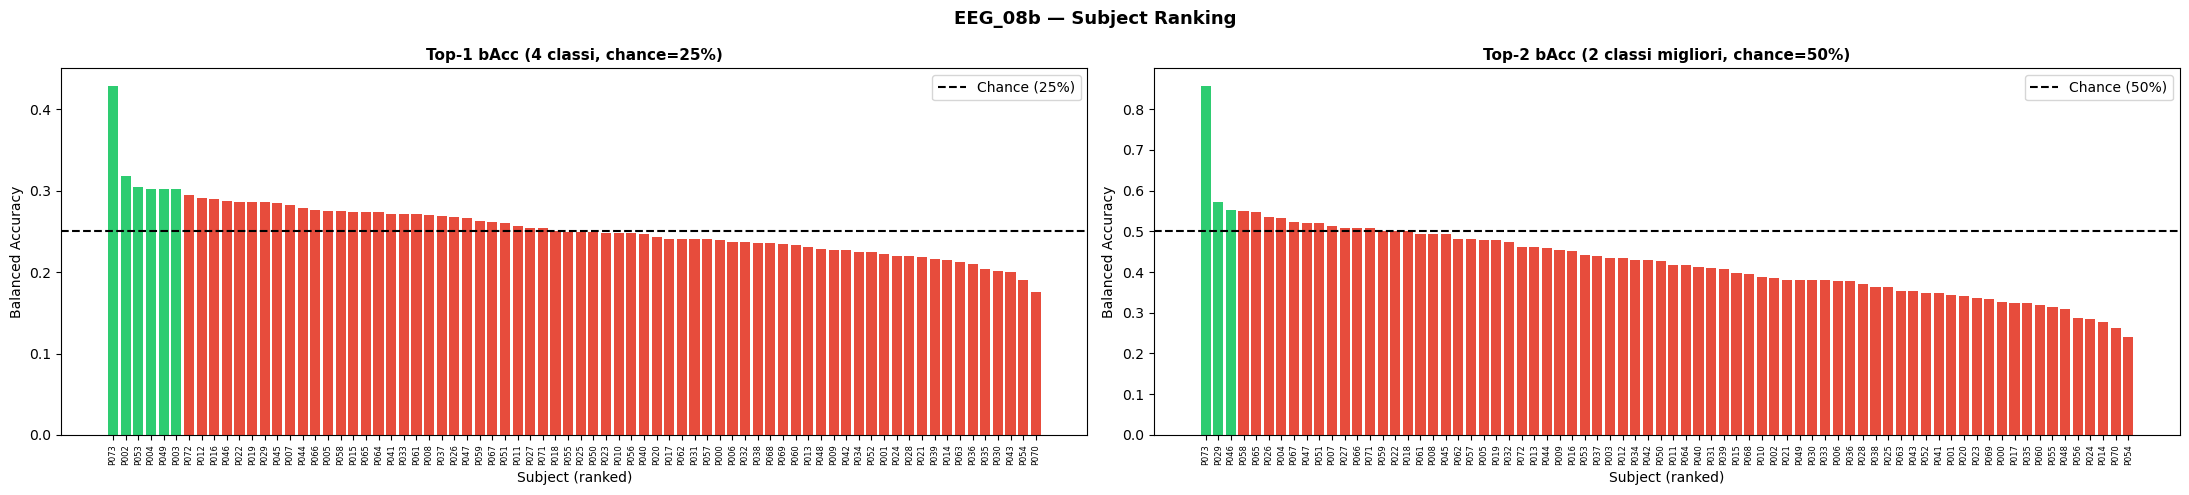

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(22, 5))

for ax, df, chance, title, col in [
    (axes[0], df_top1, chance_top1, 'Top-1 bAcc (4 classi, chance=25%)', 'Top1 bAcc'),
    (axes[1], df_top2, chance_top2, 'Top-2 bAcc (2 classi migliori, chance=50%)', 'Top2 bAcc'),
]:
    colors = ['#2ecc71' if v > chance + 0.05 else '#e74c3c' for v in df[col]]
    ax.bar(df['Subject'], df[col], color=colors, edgecolor='none')
    ax.axhline(chance, color='black', lw=1.5, linestyle='--',
               label=f'Chance ({chance:.0%})')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Subject (ranked)', fontsize=10)
    ax.set_ylabel('Balanced Accuracy', fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.legend()

fig.suptitle('EEG_08b — Subject Ranking', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(project_root / 'figures' / 'eeg08b_ranking_top1_top2.png',
            dpi=150, bbox_inches='tight')
plt.show()


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


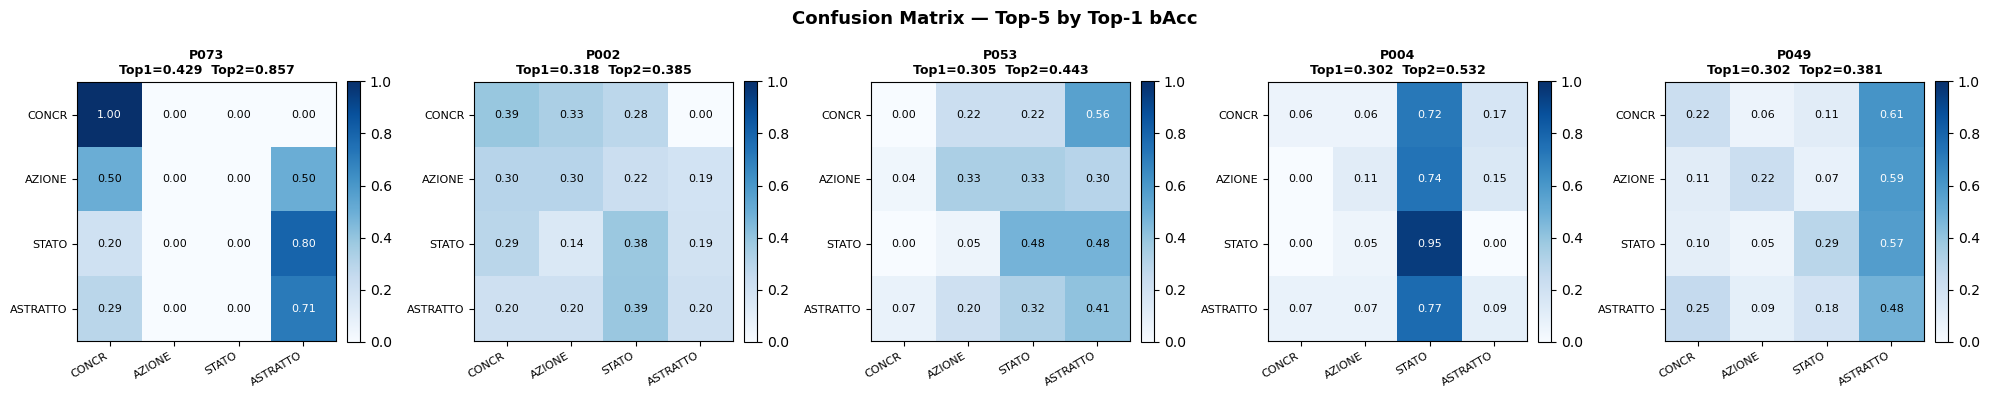

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


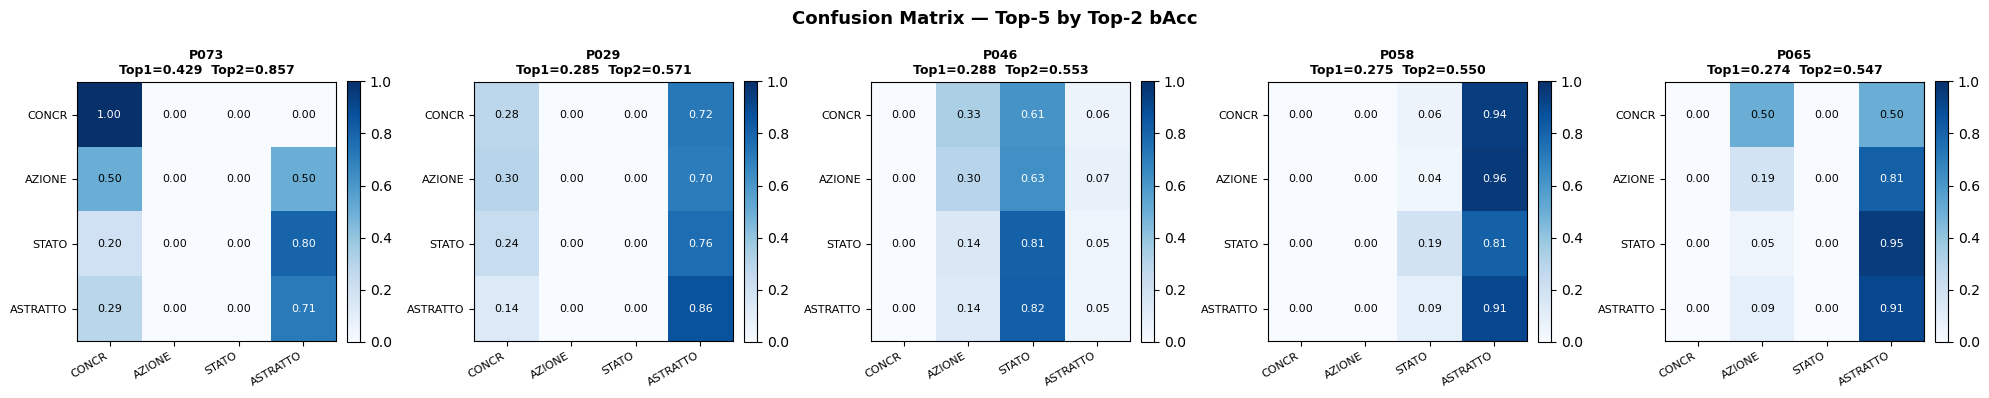

Confusion matrix salvate.


In [18]:
def plot_cm_grid(df_rank, col, title_prefix, filename):
    top5      = df_rank.head(5)['Subject'].tolist()
    top5_ids  = [int(s[1:]) for s in top5]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'Confusion Matrix — Top-5 by {title_prefix}',
                 fontsize=13, fontweight='bold')
    for ax, sid, sname in zip(axes, top5_ids, top5):
        res = SUBJECT_RESULTS[sid]
        cm  = res['cm'].astype(float)
        cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(4))
        ax.set_xticklabels(LABEL_NAMES, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(4))
        ax.set_yticklabels(LABEL_NAMES, fontsize=8)
        t2, t2c = top2_bacc(res['labels'], res['preds'])
        ax.set_title(
            f"{sname}\nTop1={res['test_bacc']:.3f}  Top2={t2:.3f}",
            fontsize=9, fontweight='bold'
        )
        for i in range(4):
            for j in range(4):
                ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                        fontsize=8,
                        color='white' if cm_norm[i,j] > 0.5 else 'black')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(project_root / 'figures' / filename, dpi=150, bbox_inches='tight')
    plt.show()


# verifica che labels/preds siano in SUBJECT_RESULTS
has_preds = all('labels' in r and 'preds' in r
                for r in SUBJECT_RESULTS.values())
if not has_preds:
    print('labels/preds non salvati — riesegui con il nuovo evaluate()')
else:
    plot_cm_grid(df_top1, 'Top1 bAcc', 'Top-1 bAcc', 'eeg08b_cm_top1.png')
    plot_cm_grid(df_top2, 'Top2 bAcc', 'Top-2 bAcc', 'eeg08b_cm_top2.png')
    print('Confusion matrix salvate.')
